# Time Series Fraud Patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path

# Find project root and set working directory
current = Path.cwd()
while current.name != "credit_fraud_ml":
    current = current.parent
os.chdir(current)
sys.path.append(str(current))

from src.data.data_loader import DataLoader

loader = DataLoader()
data = loader.load_all('train')
transactions = data['transactions']

# Pre-extract time features used across all cells
transactions = transactions.sort_values('TX_DATETIME').reset_index(drop=True)
transactions['TX_DATE']  = transactions['TX_DATETIME'].dt.date
transactions['TX_HOUR']  = transactions['TX_DATETIME'].dt.hour
transactions['TX_DAY']   = transactions['TX_DATETIME'].dt.dayofweek
transactions['TX_WEEK']  = transactions['TX_DATETIME'].dt.isocalendar().week.astype(int)

print(f"Date range: {transactions['TX_DATETIME'].min()} → {transactions['TX_DATETIME'].max()}")
print(f"Total transactions: {len(transactions):,}")

✓ Loaded 291,231 train transactions
✓ Loaded 1,000 customers
✓ Loaded 2,000 terminals
Date range: 2021-08-01 00:04:37 → 2021-12-30 23:58:21
Total transactions: 291,231


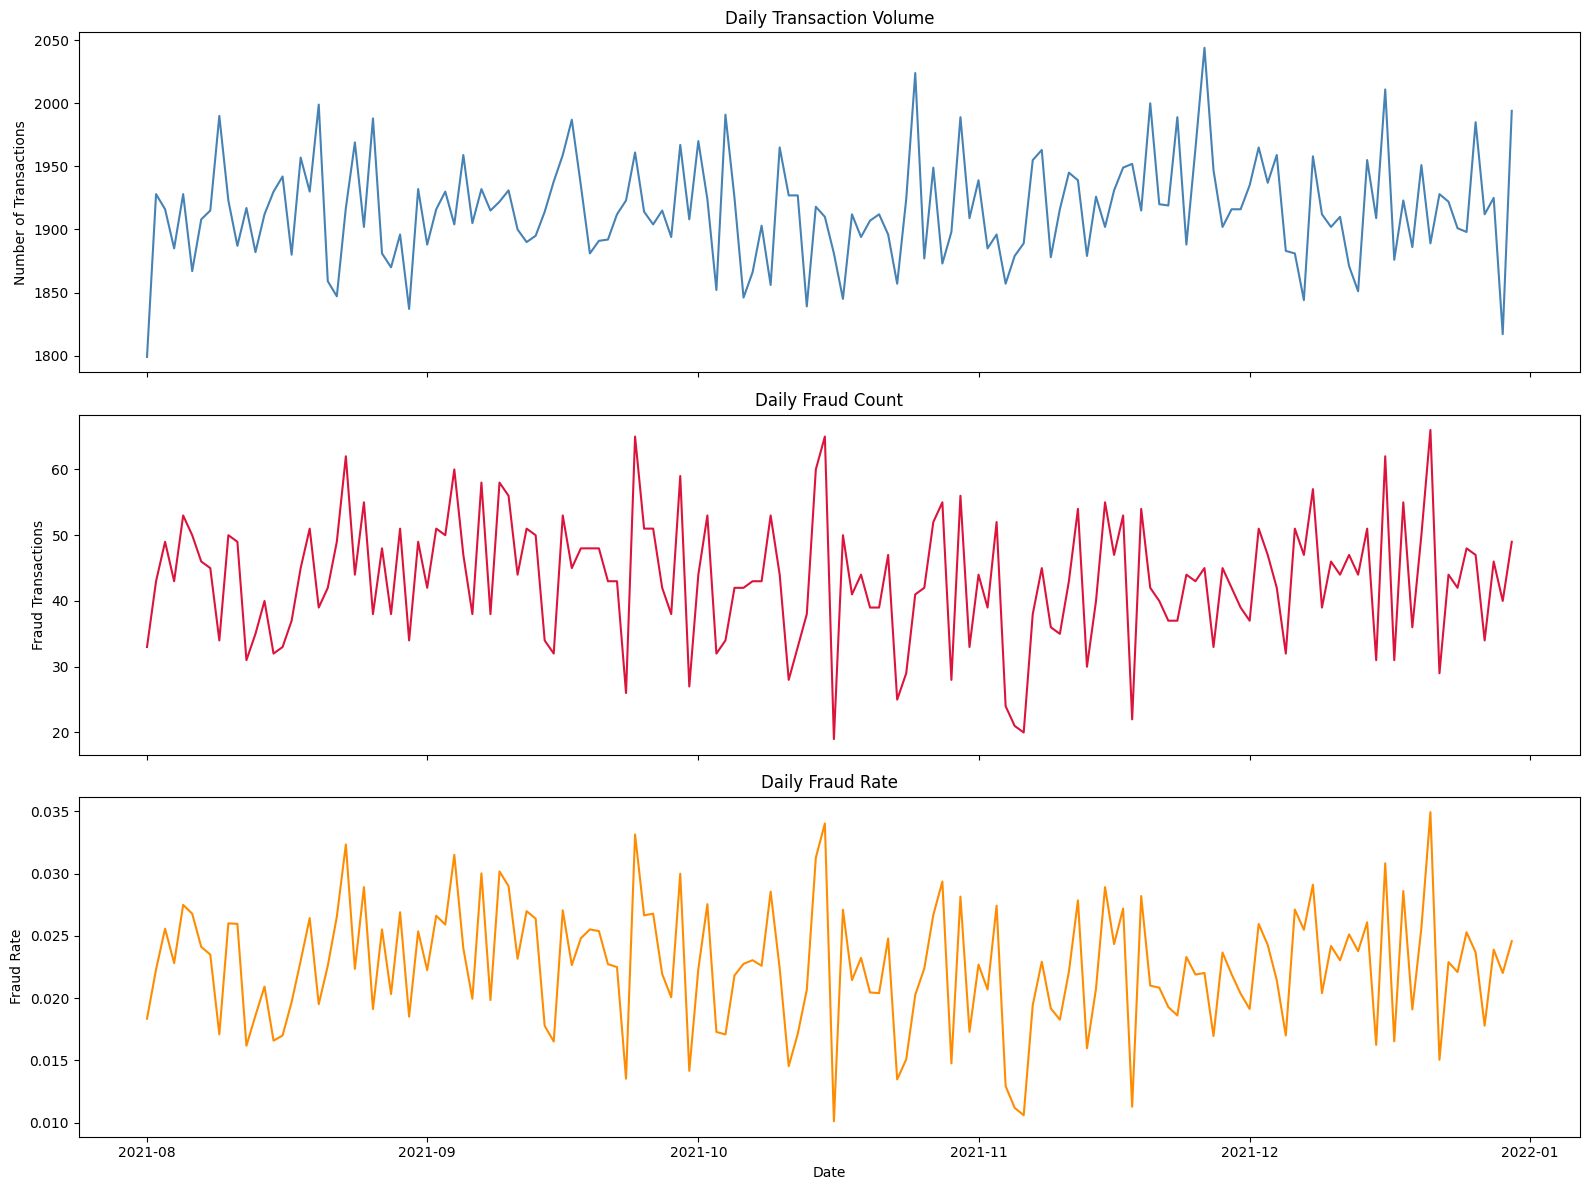

In [2]:
# ── 1. Daily Transaction Volume & Fraud Count ──────────────────────────────
daily = transactions.groupby('TX_DATE').agg(
    total=('TX_FRAUD', 'count'),
    fraud=('TX_FRAUD', 'sum')
)
daily['fraud_rate'] = daily['fraud'] / daily['total']

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(daily.index, daily['total'], color='steelblue')
axes[0].set_title('Daily Transaction Volume')
axes[0].set_ylabel('Number of Transactions')

axes[1].plot(daily.index, daily['fraud'], color='crimson')
axes[1].set_title('Daily Fraud Count')
axes[1].set_ylabel('Fraud Transactions')

axes[2].plot(daily.index, daily['fraud_rate'], color='darkorange')
axes[2].set_title('Daily Fraud Rate')
axes[2].set_ylabel('Fraud Rate')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

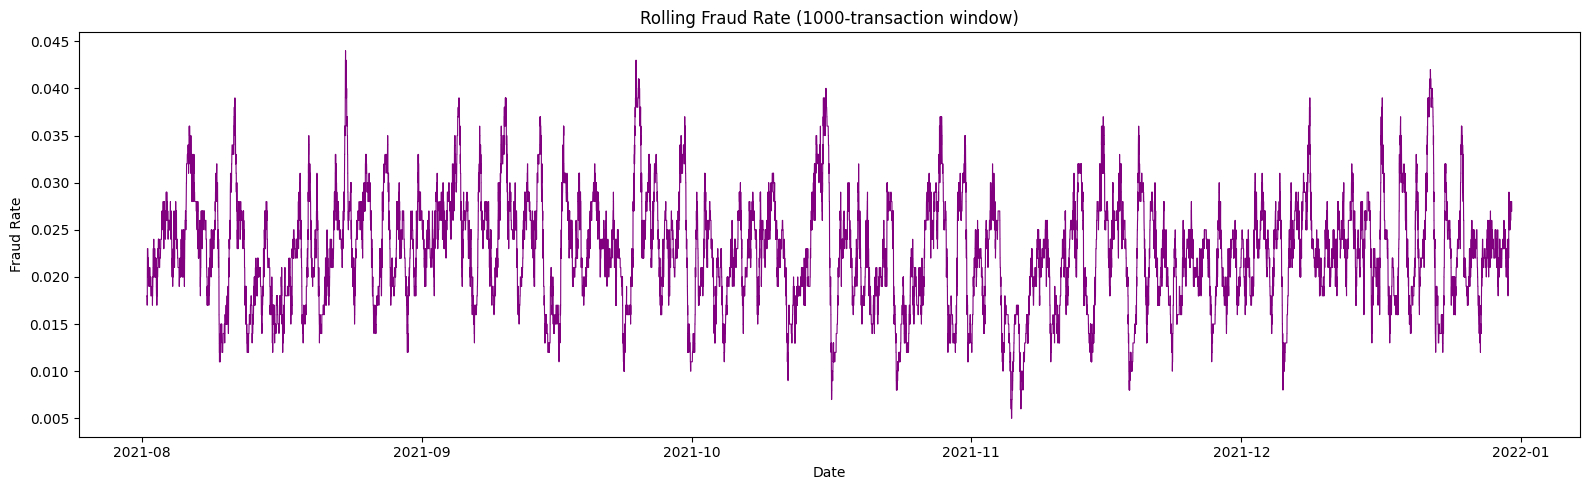

In [3]:
# ── 2. Rolling Fraud Rate (window = 1000 transactions) ─────────────────────
transactions['rolling_fraud_rate'] = transactions['TX_FRAUD'].rolling(1000).mean()

plt.figure(figsize=(16, 5))
plt.plot(transactions['TX_DATETIME'], transactions['rolling_fraud_rate'], color='purple', linewidth=0.8)
plt.title('Rolling Fraud Rate (1000-transaction window)')
plt.xlabel('Date')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

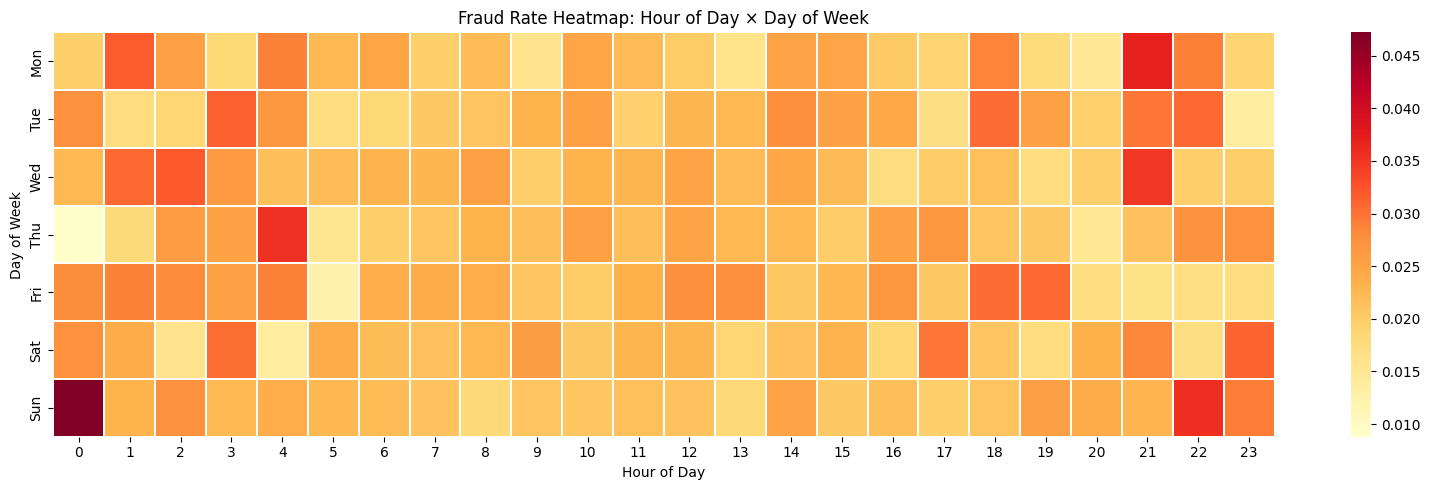

In [4]:
# ── 3. Hourly Heatmap: Fraud Rate by Hour × Day of Week ────────────────────
pivot = transactions.groupby(['TX_DAY', 'TX_HOUR'])['TX_FRAUD'].mean().unstack()
pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, linewidths=0.3)
plt.title('Fraud Rate Heatmap: Hour of Day × Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

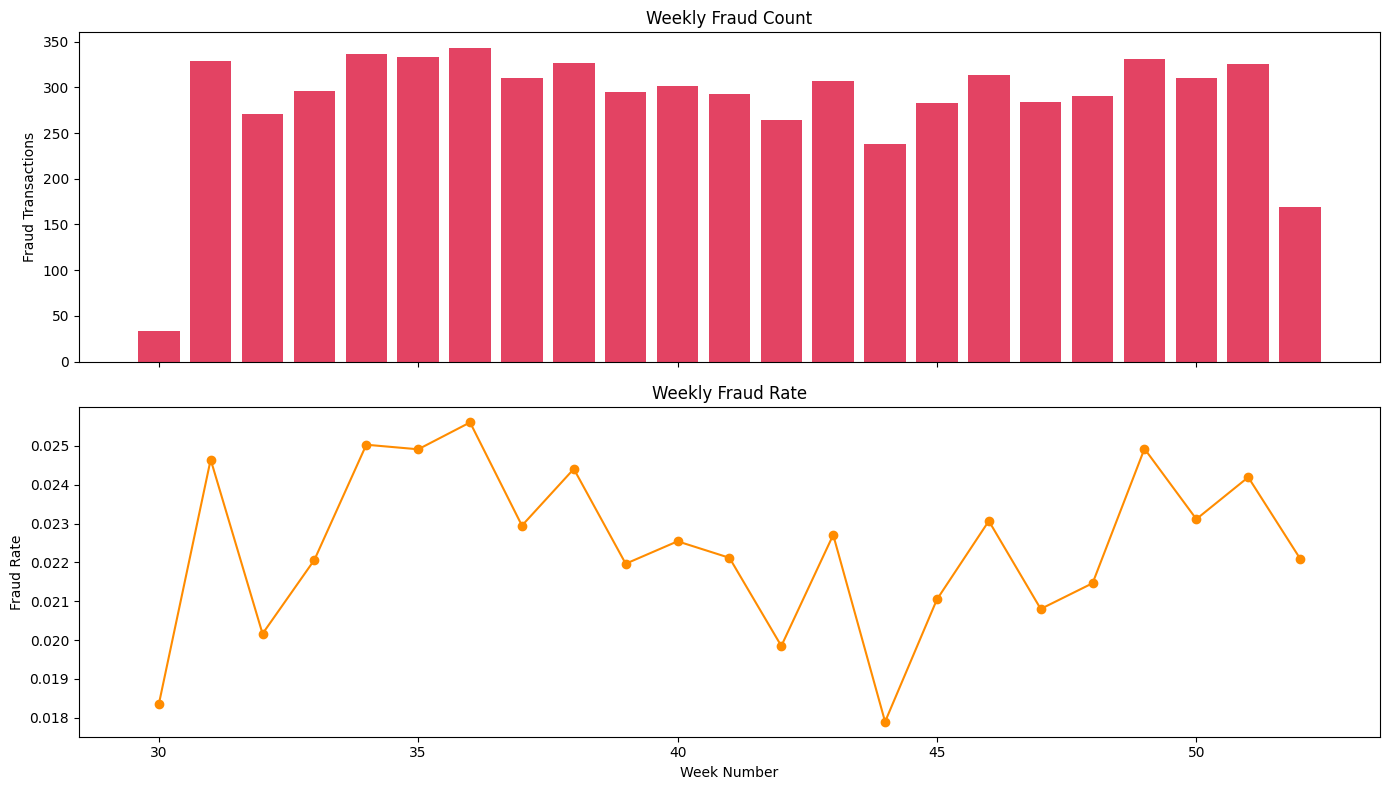

In [5]:
# ── 4. Weekly Fraud Trend ───────────────────────────────────────────────────
weekly = transactions.groupby('TX_WEEK').agg(
    total=('TX_FRAUD', 'count'),
    fraud=('TX_FRAUD', 'sum')
)
weekly['fraud_rate'] = weekly['fraud'] / weekly['total']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(weekly.index, weekly['fraud'], color='crimson', alpha=0.8)
axes[0].set_title('Weekly Fraud Count')
axes[0].set_ylabel('Fraud Transactions')

axes[1].plot(weekly.index, weekly['fraud_rate'], marker='o', color='darkorange')
axes[1].set_title('Weekly Fraud Rate')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_xlabel('Week Number')

plt.tight_layout()
plt.show()

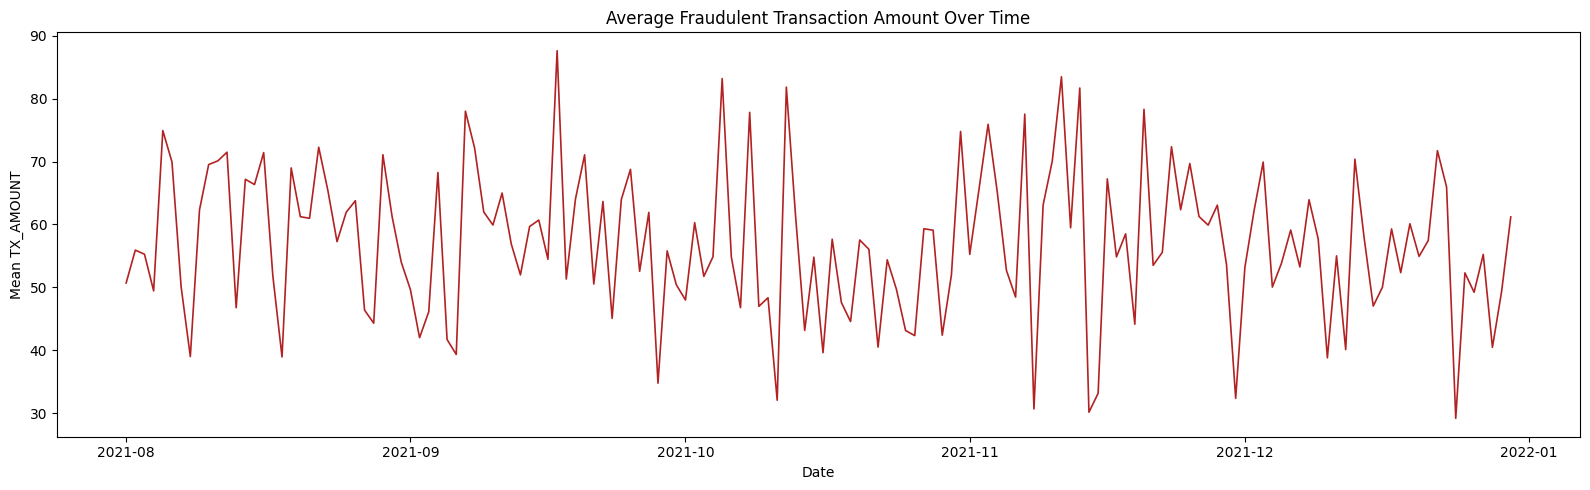

Overall mean fraud amount : $57.16
Overall mean legit amount : $53.09


In [6]:
# ── 5. Average Fraud Amount Over Time ──────────────────────────────────────
fraud_only = transactions[transactions['TX_FRAUD'] == 1]
daily_fraud_amount = fraud_only.groupby('TX_DATE')['TX_AMOUNT'].mean()

plt.figure(figsize=(16, 5))
plt.plot(daily_fraud_amount.index, daily_fraud_amount.values, color='firebrick', linewidth=1.2)
plt.title('Average Fraudulent Transaction Amount Over Time')
plt.xlabel('Date')
plt.ylabel('Mean TX_AMOUNT')
plt.tight_layout()
plt.show()

print(f"Overall mean fraud amount : ${fraud_only['TX_AMOUNT'].mean():.2f}")
print(f"Overall mean legit amount : ${transactions[transactions['TX_FRAUD']==0]['TX_AMOUNT'].mean():.2f}")